In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Go up one level from doomsday/ to habitability/
sys.path.insert(0, str(Path.cwd().parent))
from calculator import SeaIceCalc, Habitability, SST, SRD, Tempdiff, Tempdiffall

Open the file

In [3]:
file = "../../earth/output_final.nc"
ds = xr.open_dataset(file)
# ds_crop = ds.sel(time=slice("2002-01-01", "2002-12-31"))

Extract habitability for each month

In [4]:
results_hab = []
yearly_data = ds.groupby("time.year")

In [5]:
for year, year_ds in yearly_data:

    hab = {
        "month": None,
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
    }

    monthly_data = year_ds.groupby("time.month")
    months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
    hab["month"] = months

    for month, month_ds in monthly_data:

        # Whole globe
        fraction_sm = Habitability.fraction(month_ds, "sm")[0]
        fraction_st = Habitability.fraction(month_ds, "st")[0]
        fraction_tsurf = Habitability.fraction(month_ds, "tsurf")[0]

        hab["sm_tot"].append(fraction_sm)
        hab["st_tot"].append(fraction_st)
        hab["tsurf_tot"].append(fraction_tsurf)
    
        # Northern hemisphere
        sm_n = Habitability.fraction(month_ds, "sm", lat=slice(0,24))[0]
        st_n = Habitability.fraction(month_ds, "st", lat=slice(0,24))[0]
        tsurf_n = Habitability.fraction(month_ds, "tsurf", lat=slice(0,24))[0]

        hab["sm_nhem"].append(sm_n)
        hab["st_nhem"].append(st_n)
        hab["tsurf_nhem"].append(tsurf_n)

        # Southern hemisphere
        sm_s = Habitability.fraction(month_ds, "sm", lat=slice(24,48))[0]
        st_s = Habitability.fraction(month_ds, "st", lat=slice(24,48))[0]
        tsurf_s = Habitability.fraction(month_ds, "tsurf", lat=slice(24,48))[0]

        hab["sm_shem"].append(sm_s)
        hab["st_shem"].append(st_s)
        hab["tsurf_shem"].append(tsurf_s)
    
    # convert lists of scalars to numpy arrays for math/plotting later
    for k, v in list(hab.items()):
        # keep 'month' as-is (already an array)
        if k == "month":
            continue
        # convert lists to numpy arrays
        if isinstance(v, list):
            hab[k] = np.array(v) 
    
    # Store results
    results_hab.append({"year": year, "data": hab})

In [6]:
# fig = plt.figure(figsize=(10, 5))
# for yr_dict in results_hab:
#     year = yr_dict["year"]
#     month = yr_dict["data"]["month"]
#     st = yr_dict["data"]["st_tot"]
#     plt.plot(month, st, label=f"Year {year}", marker='o')

# plt.xlabel("Month")
# plt.title("Soil Temperature")
# plt.ylabel("Habitability Fraction")
# plt.legend()
# plt.show()

# fig = plt.figure(figsize=(10, 5))
# for yr_dict in results_hab:
#     year = yr_dict["year"]
#     month = yr_dict["data"]["month"]
#     st = yr_dict["data"]["st_nhem"]
#     plt.plot(month, st, label=f"Year {year}", marker='o')

# plt.xlabel("Month")
# plt.title("Soil Temperature Northern Hemisphere")
# plt.ylabel("Habitability Fraction")
# plt.legend()
# plt.show()

# fig = plt.figure(figsize=(10, 5))
# for yr_dict in results_hab:
#     year = yr_dict["year"]
#     month = yr_dict["data"]["month"]
#     st = yr_dict["data"]["st_shem"]
#     plt.plot(month, st, label=f"Year {year}", marker='o')

# plt.xlabel("Month")
# plt.title("Soil Temperature Southern Hemisphere")
# plt.ylabel("Habitability Fraction")
# plt.legend()
# plt.show()

# fig = plt.figure(figsize=(10, 5))
# for yr_dict in results_hab:
#     year = yr_dict["year"]
#     month = yr_dict["data"]["month"]
#     sm = yr_dict["data"]["sm_tot"]
#     plt.plot(month, sm, label=f"Year {year}", marker='o')

# plt.xlabel("Month")
# plt.title("Soil Moisture")
# plt.ylabel("Habitability Fraction")
# plt.legend()
# plt.show()

# fig = plt.figure(figsize=(10, 5))
# for yr_dict in results_hab:
#     year = yr_dict["year"]
#     month = yr_dict["data"]["month"]
#     sm = yr_dict["data"]["sm_tot"]
#     plt.plot(month, sm, label=f"Year {year}", marker='o')

# plt.xlabel("Month")
# plt.ylim(89,90)
# plt.title("Soil Moisture")
# plt.ylabel("Habitability Fraction")
# plt.legend()
# plt.show()

# fig = plt.figure(figsize=(10, 5))
# for yr_dict in results_hab:
#     year = yr_dict["year"]
#     month = yr_dict["data"]["month"]
#     tsurf = yr_dict["data"]["tsurf_tot"]
#     plt.plot(month, tsurf, label=f"Year {year}", marker='o')

# plt.xlabel("Month")
# plt.title("Surface Air Temperature")
# plt.ylabel("Habitability Fraction")
# plt.legend()
# plt.show()

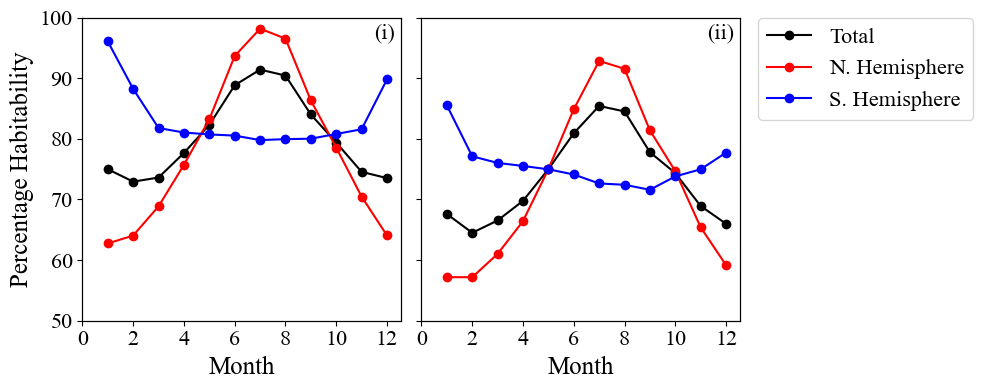

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Global Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

year_2003 = next(item for item in results_hab if item["year"] == 2001)
data_2003 = year_2003["data"]

fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

ax2_0 = ax[0].twinx()
ax2_1 = ax[1].twinx()

month = data_2003["month"]

# -------- First plot --------
ax[0].plot(month, data_2003["st_tot"], marker='o', color="black")
ax[0].plot(month, data_2003["st_nhem"], marker='o', color="red")
ax[0].plot(month, data_2003["st_shem"], marker='o', color="blue")

ax[0].set_xlabel("Month", fontsize=18)
ax[0].set_ylabel("Percentage Habitability", fontsize=18)

ax[0].set_xticks([0,2,4,6,8,10,12])
ax[0].text(0.98, 0.98, "(i)", transform=ax[0].transAxes,
           ha="right", va="top", fontsize=16)

# -------- Second plot --------
ax[1].plot(month, data_2003["tsurf_tot"], marker='o', color="black")
ax[1].plot(month, data_2003["tsurf_nhem"], marker='o', color="red")
ax[1].plot(month, data_2003["tsurf_shem"], marker='o', color="blue")

ax[1].set_xlabel("Month", fontsize=18)

ax[1].set_xticks([0,2,4,6,8,10,12])
ax[1].text(0.98, 0.98, "(ii)", transform=ax[1].transAxes,
           ha="right", va="top", fontsize=16)

# -------- Force Y limits AFTER plotting --------
for a in [ax[0], ax[1], ax2_0, ax2_1]:
    a.set_ylim(50, 100)

ax[0].set_yticks([50,60,70,80,90,100])

# Remove right-axis ticks (optional clean look)
ax2_0.set_yticks([])
ax2_1.set_yticks([])

ax[0].tick_params(axis='both', labelsize=16)
ax[1].tick_params(axis='both', labelsize=16)

# -------- Legend closer --------
fig.legend(["Total", "N. Hemisphere", "S. Hemisphere"],
           loc="lower left",
           bbox_to_anchor=(0.94, 0.66),  # closer to plots
           fontsize=16)

plt.tight_layout(rect=[0, 0, 0.95, 1])
# plt.savefig("earth_season_hab.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
from timeseries_calc import OceanParam, WholeGlobeParam, LandParam, SeaIce
ds_crop = ds.sel(time=slice("2001-01-01", "2002-1-1"))
times = ds_crop.time.dt.dayofyear.values

In [9]:
sm = Habitability.fraction(ds_crop, "sm")[0]
st = Habitability.fraction(ds_crop, "st")[0]
ts = Habitability.fraction(ds_crop, "tsurf")[0]

print(sm,st,ts)

89.47714203510738 78.1369727396264 71.33894496367546


In [36]:
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

def add_lon_lat(ax, xticks=None, yticks=None, fontsize=18, 
                left=True, bottom=True):
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.4,
        color='gray',
        alpha=0.5,
        linestyle='--'
    )

    gl.top_labels = False
    gl.right_labels = False
    
    # These toggles remove the interior labels
    gl.left_labels = left
    gl.bottom_labels = bottom

    gl.xlabel_style = {'size': fontsize}
    gl.ylabel_style = {'size': fontsize}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # Pull labels closer to the map to save space
    gl.xpadding = 2
    gl.ypadding = 2

    if xticks is not None:
        gl.xlocator = mticker.FixedLocator(xticks)
    if yticks is not None:
        gl.ylocator = mticker.FixedLocator(yticks)

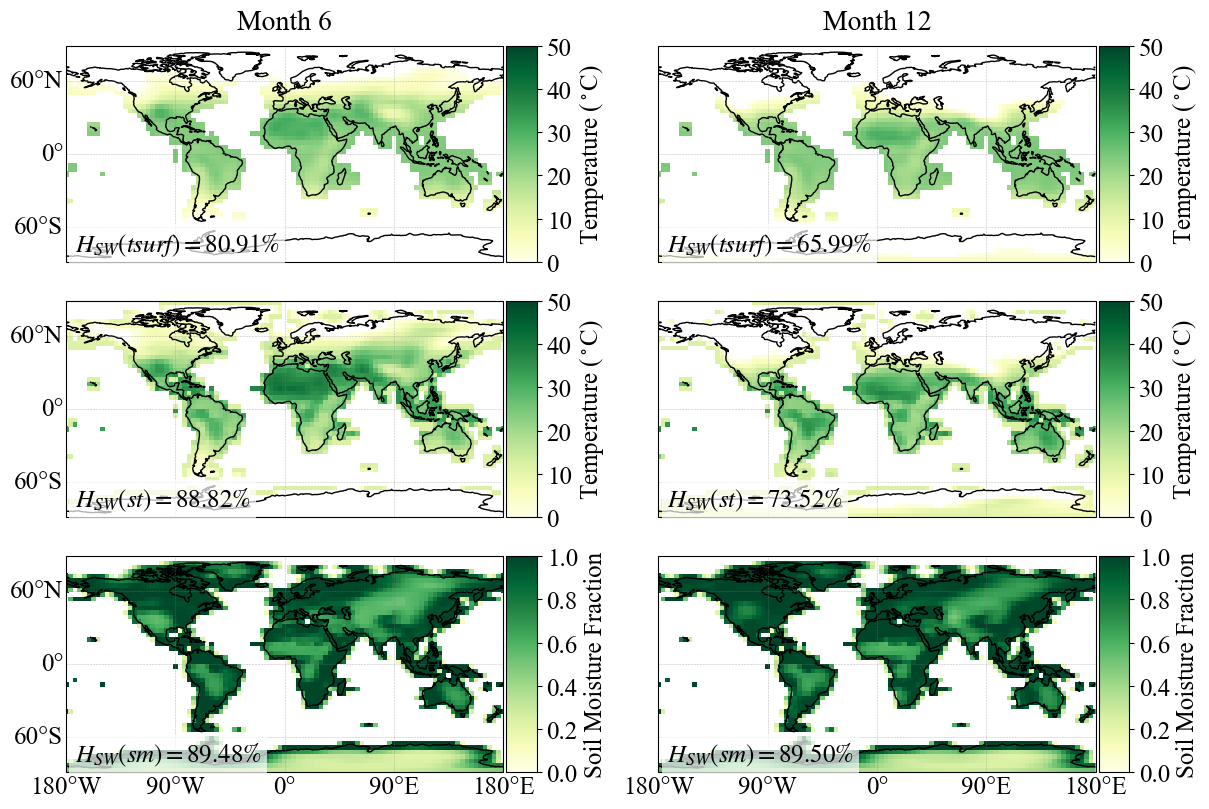

In [50]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable

months_to_keep = [6, 12]
row_vars = ["tsurf", "st", "sm"]

fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(12.2, 8.2),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

var_labels = {
    "tsurf": "Surface Air Temp",
    "st": "Soil Temp",
    "sm": "Soil Moisture"
}

ticks_temp = [0, 10, 20, 30, 40, 50]
ticks_sm = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
cmap = "YlGn"
grouped = ds_crop.groupby("time.month")

for i, varname in enumerate(row_vars):
    for j, month in enumerate(months_to_keep):
        ax = axes[i, j]
        month_ds = grouped[month]

        fraction, mean_plot, habitable_plot = Habitability.fraction(month_ds, varname)
        axes[0, j].set_title(f"Month {month}", fontsize=20, pad=12)

        # variable-specific scale/ticks/label
        if varname == "sm":
            vmin, vmax = 0, 1
            ticks = ticks_sm
            label = "Soil Moisture Fraction"
        else:
            vmin, vmax = 0, 50
            ticks = ticks_temp
            label = r"Temperature ($^\circ$C)"

        # Plot WITHOUT automatic colorbar/labels (prevents auto "soil layer" title)
        im = mean_plot.where(habitable_plot).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False,
            add_labels=False
        )

        # Create a dedicated cax next to the map for a wider colorbar
        divider = make_axes_locatable(ax)
        # Use axes_class=plt.Axes so the new axes doesn't try to be a GeoAxes (avoids KeyError)
        # size controls width: "5%" small, "7%" moderate, "10%" wide
        cax = divider.append_axes("right", size="7%", pad=0.03, axes_class=plt.Axes)

        # Attach colorbar to that cax (same height as plot, width controlled by `size`)
        cbar = fig.colorbar(im, cax=cax, orientation="vertical")
        cbar.set_label(label, fontsize=18)
        cbar.set_ticks(ticks)
        cbar.ax.tick_params(labelsize=18)

        # map styling
        ax.coastlines()
        # ax.add_feature(cfeature.BORDERS, linewidth=0.5)


        ax.text(
            0.02, 0.02,
            rf"$H_{{SW}}({varname}) = {fraction:.2f}\%$",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=18,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        add_lon_lat(
            ax,
            xticks=[-180, -90, 0, 90, 180],
            yticks=[-60, 0, 60],
            left=(j == 0),
            bottom=(i == len(row_vars) - 1)
        )

        # ax.set_title(f"{var_labels[varname]}, Month {month}", fontsize=16)
        
plt.tight_layout()
plt.savefig("earth_maps.png", dpi=300, bbox_inches='tight')
plt.show()

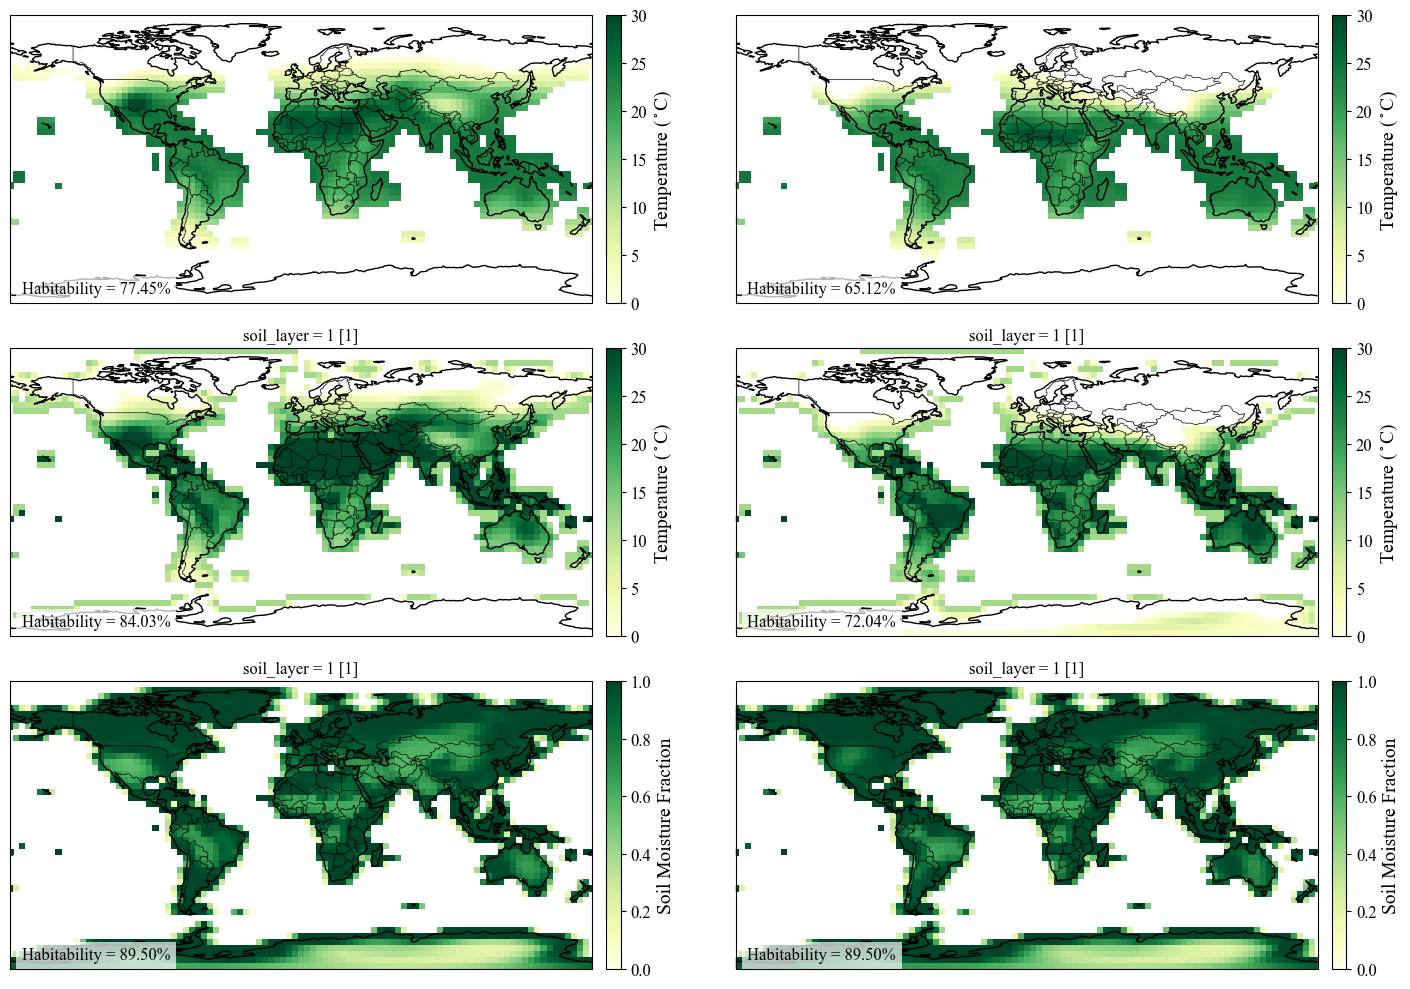

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

months_to_keep = [6, 12]
row_vars = ["tsurf", "st", "sm"]

fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(15, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ticks_temp = [0, 5, 10, 15, 20, 25, 30]
ticks_sm = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

cmap = "YlGn"
grouped = ds_crop.groupby("time.month")

for i, varname in enumerate(row_vars):
    for j, month in enumerate(months_to_keep):

        ax = axes[i, j]
        month_ds = grouped[month]

        fraction, mean_plot, habitable_plot = Habitability.fraction(month_ds, varname)

        # ---- Set variable-specific scaling and ticks ----
        if varname == "sm":
            vmin = 0
            vmax = 1
            ticks = ticks_sm
            label = "Soil Moisture Fraction"
        else:
            vmin = 0
            vmax = 30
            ticks = ticks_temp
            label = r"Temperature ($^\circ$C)"

        # ---- Plot WITHOUT automatic colorbar ----
        im = mean_plot.where(habitable_plot).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=vmin,              # force start at 0
            vmax=vmax,
            add_colorbar=False
        )

        # ---- Add wider manual colorbar ----
        cbar = fig.colorbar(
            im,
            ax=ax,
            orientation="vertical",
            fraction=0.05,   # increase for wider bar (0.05 default-ish)
            pad=0.02
        )

        cbar.set_label(label, fontsize=14)
        cbar.set_ticks(ticks)
        cbar.ax.tick_params(labelsize=12)

        # ---- Map styling ----
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(
            0.02, 0.02,
            f"Habitability = {fraction:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=12,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

plt.tight_layout()
plt.show()

In [ ]:
frac_st = Habitability.fraction(ds_crop, "st")[0]
frac_sm = Habitability.fraction(ds_crop, "sm")[0]
frac_ts = Habitability.fraction(ds_crop, "tsurf")[0]
print(frac_sm,frac_st,frac_ts)

89.49722674857468 76.92556527311515 70.74404278137712


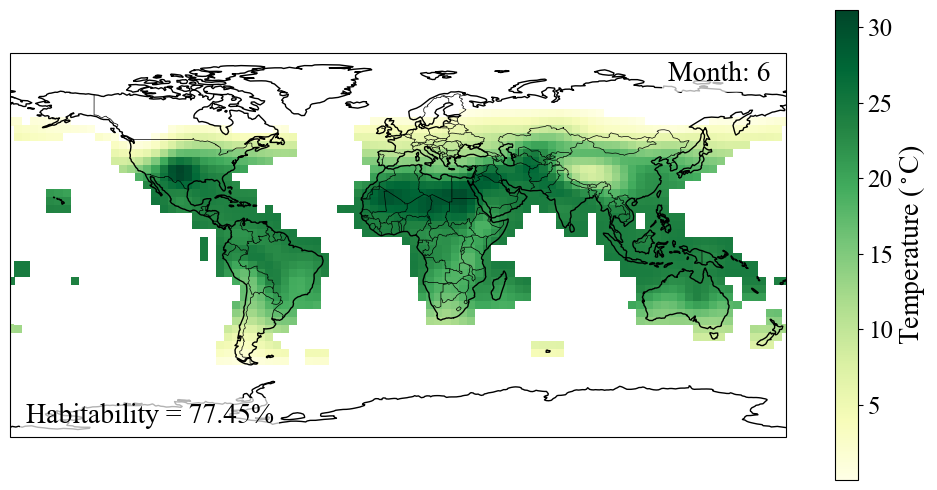

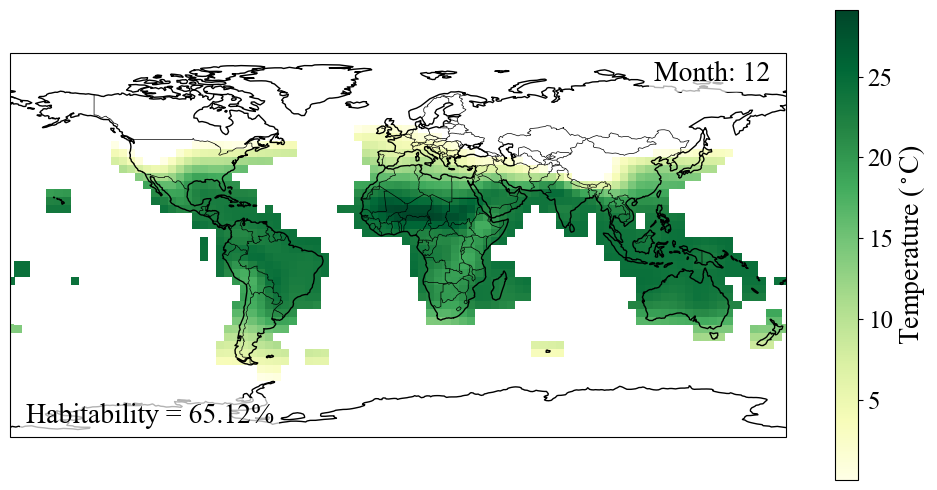

In [ ]:
# Surface air temperature maps

grouped_data = ds_crop.groupby("time.month")

months_to_keep = [6,12]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        # Soil Moisture
        fraction = Habitability.fraction(month_ds, "tsurf")[0]
        mean_plot = Habitability.fraction(month_ds, "tsurf")[1]
        habitable_plot = Habitability.fraction(month_ds, "tsurf")[2]

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        ticks = [0, 5, 10, 15, 20, 25, 30]

        im = mean_plot.where(habitable_plot).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="YlGn",
        cbar_kwargs={
            "label": r"Temperature ($^\circ$C)",
            "ticks": ticks}
        )

        cbar = im.colorbar
        cbar.ax.yaxis.label.set_size(20)   # label size
        cbar.ax.tick_params(labelsize=18)

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Habitability = {fraction:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=20,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        ax.text(
        0.98, 0.98,
        f"Month: {month}",
        transform=ax.transAxes,
        fontsize=20,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )
    
        plt.tight_layout()

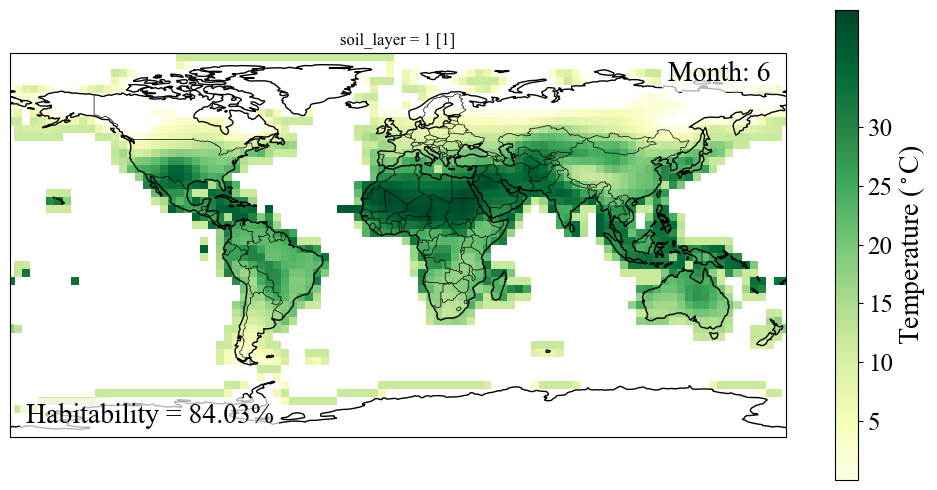

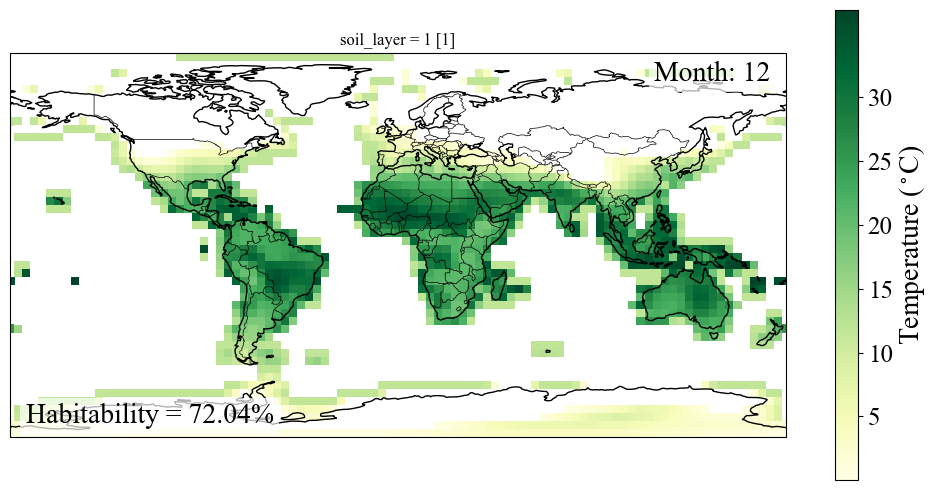

In [ ]:
# Soil temperature maps

months_to_keep = [6,12]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        # Soil Moisture
        fraction = Habitability.fraction(month_ds, "st")[0]
        mean_plot = Habitability.fraction(month_ds, "st")[1]
        habitable_plot = Habitability.fraction(month_ds, "st")[2]

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        ticks = [0, 5, 10, 15, 20, 25, 30]

        im = mean_plot.where(habitable_plot).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="YlGn",
        cbar_kwargs={
            "label": r"Temperature ($^\circ$C)",
            "ticks": ticks}
        )

        cbar = im.colorbar
        cbar.ax.yaxis.label.set_size(20)   # label size
        cbar.ax.tick_params(labelsize=18)

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Habitability = {fraction:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=20,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        ax.text(
        0.98, 0.98,
        f"Month: {month}",
        transform=ax.transAxes,
        fontsize=20,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )
    
        plt.tight_layout()

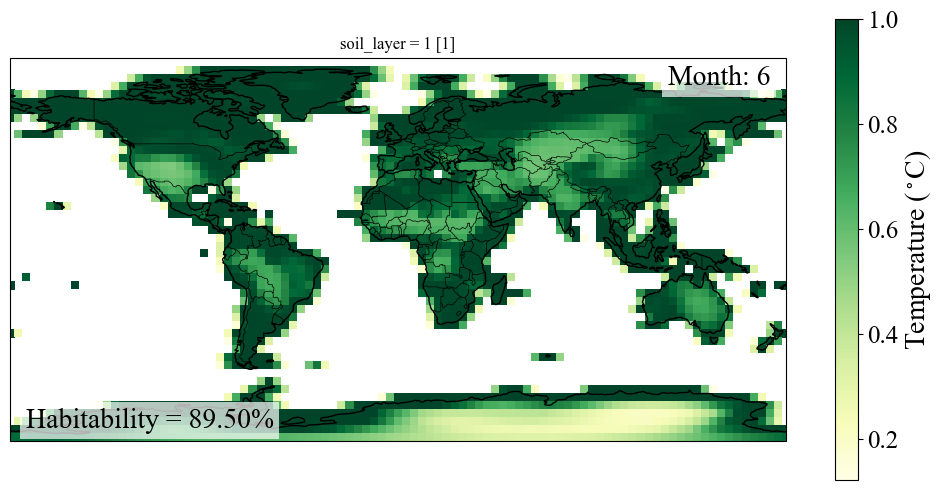

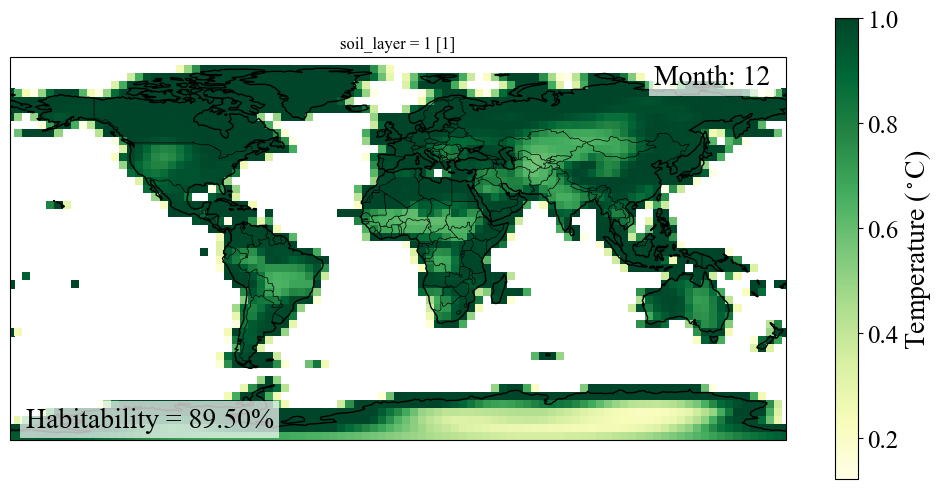

In [ ]:
# Surface air temperature maps

for month, month_ds in grouped_data:
    if month in months_to_keep:

        # Soil Moisture
        fraction = Habitability.fraction(month_ds, "sm")[0]
        mean_plot = Habitability.fraction(month_ds, "sm")[1]
        habitable_plot = Habitability.fraction(month_ds, "sm")[2]       

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

        im = mean_plot.where(habitable_plot).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="YlGn",
        cbar_kwargs={
            "label": r"Temperature ($^\circ$C)",
            "ticks": ticks}
        )

        cbar = im.colorbar
        cbar.ax.yaxis.label.set_size(20)   # label size
        cbar.ax.tick_params(labelsize=18)

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Habitability = {fraction:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=20,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        ax.text(
        0.98, 0.98,
        f"Month: {month}",
        transform=ax.transAxes,
        fontsize=20,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )
    
        plt.tight_layout()

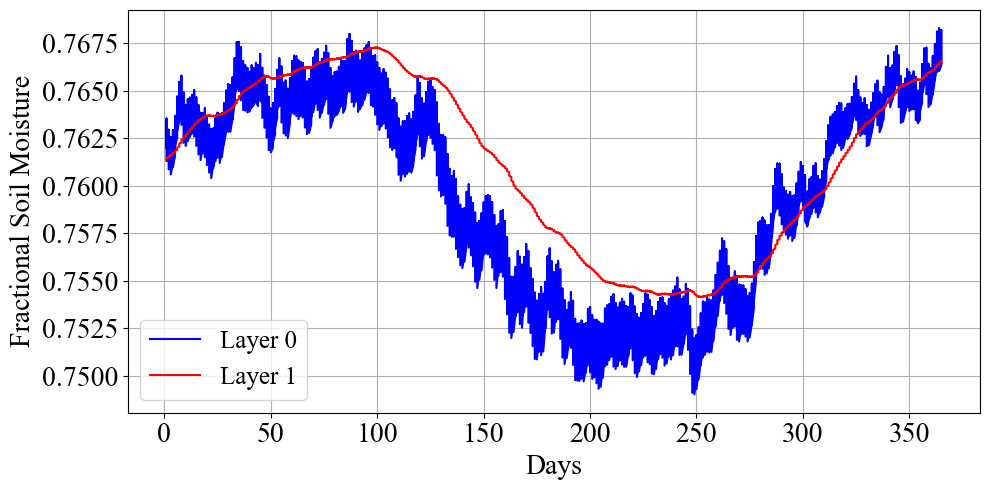

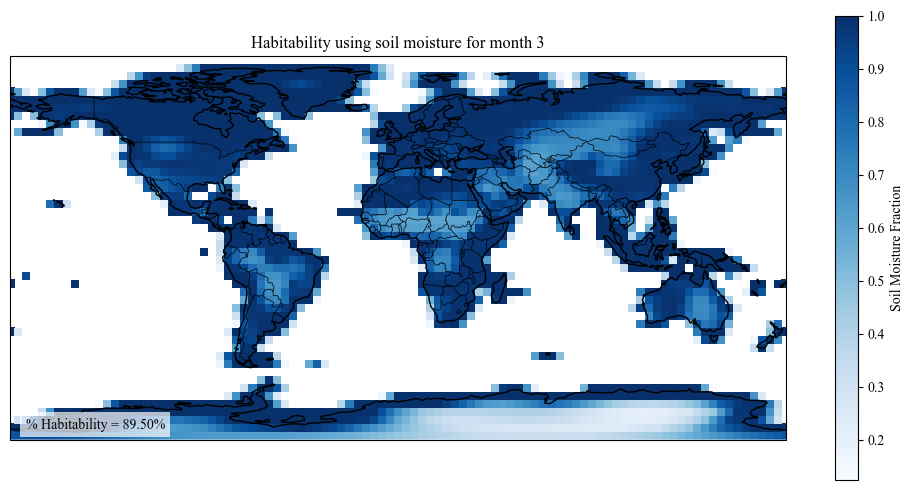

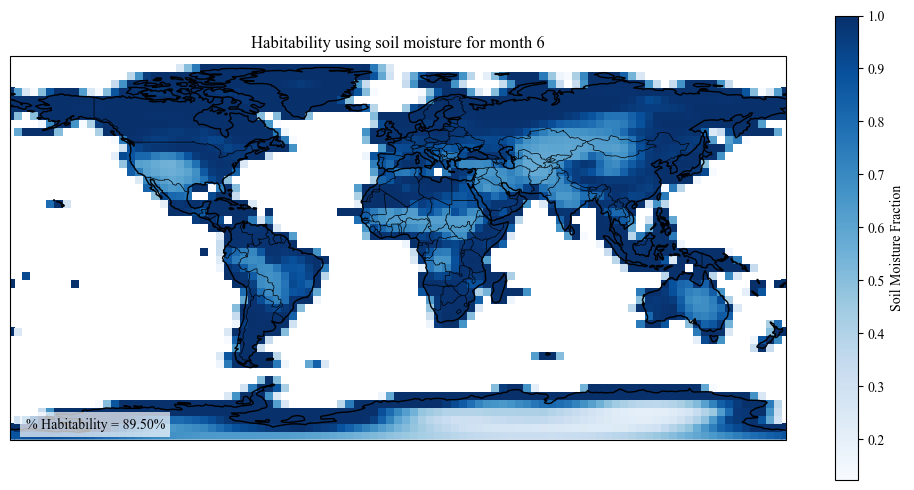

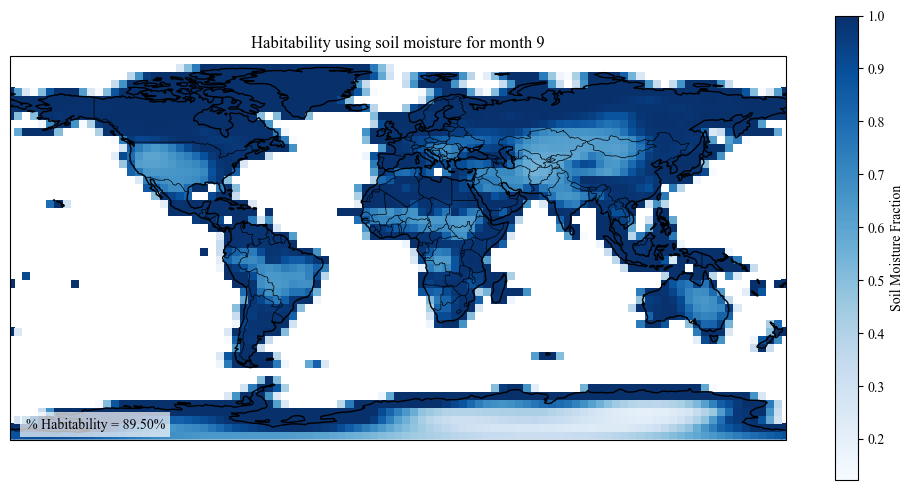

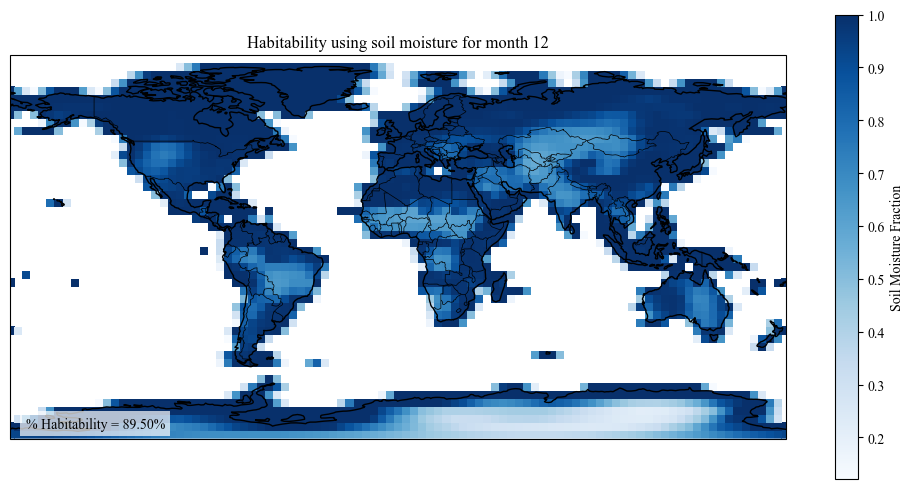

In [ ]:
sm_l0 = LandParam.landparam_timeseries(ds_crop["sm"].isel(soil_layer=0),ds_crop["lsm"])
sm_l1 = LandParam.landparam_timeseries(ds_crop["sm"].isel(soil_layer=1),ds_crop["lsm"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, sm_l0, color='blue', label="Layer 0")
plt.plot(times, sm_l1, color='red', label="Layer 1")
plt.ylabel("Fractional Soil Moisture", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

months_to_keep = [3,6,9,12]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        # Soil Moisture
        fraction = Habitability.fraction(month_ds, "sm")[0]
        mean_plot = Habitability.fraction(month_ds, "sm")[1]
        habitable_plot = Habitability.fraction(month_ds, "sm")[2]

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        mean_plot.where(habitable_plot).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Soil Moisture Fraction"},
            cmap="Blues"
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"% Habitability = {fraction:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Habitability using soil moisture for month {month}")
    
        plt.tight_layout()